# Design 1: aesthetic_basis time series under a random, ergodic environment

From `literature-notes/main-project-idea.txt`, "Series of Experiments: Design 1": treat `aesthetic_basis` as a time series and ask how it varies over a long exposure horizon, in a random, ergodic environment.

`run_simulation.run_design1()` implements this as: `num_songs` songs, each with a fixed complexity drawn once; `num_exposures` exposures drawn uniformly at random (with replacement) from that fixed pool (i.i.d. draws → ergodic); `aesthetic_basis` computed on each repeat exposure; a rolling mean over a `window`-exposure window as the time-average.

Change the parameters below and re-run the notebook to explore.

In [21]:
import sys
sys.path.insert(0, "..")
import pandas as pd
import matplotlib.pyplot as plt

from run_simulation import run_design1

NUM_SONGS = 1
NUM_EXPOSURES = 30
WINDOW = 5
SEED = 42
NOISE = 0.25   # pyactup Memory noise (overrides config.yaml when set)
DECAY = 0.5    # pyactup Memory decay (overrides config.yaml when set)

ANNOTATE_SONGS = True    # set True to label points with their song_id
ANNOTATE_MAX_LABELS = 100  # evenly-spaced label count when ANNOTATE_SONGS is True

In [22]:
df = run_design1(num_songs=NUM_SONGS, num_exposures=NUM_EXPOSURES,
                  window=WINDOW, seed=SEED, noise=NOISE, decay=DECAY,
                  config_path="../config.yaml",
                  output_path="../results/data/design1_ergodic_timeseries.csv")
df.describe()

,predicted_activation,actual_activation,aesthetic_basis,trial,complexity,aesthetic_basis_rolling_mean
count,29.000000,29.000000,29.000000,29.000000,29.0,25.000000
mean,1.497503,1.605395,0.533003,15.000000,2.0,0.547124
std,0.797745,0.673177,0.396962,8.514693,0.0,0.176100
min,-0.318984,-0.316132,0.029398,1.000000,2.0,0.213819
25%,1.069350,1.397170,0.216478,8.000000,2.0,0.437268
50%,1.490811,1.793203,0.499153,15.000000,2.0,0.528702
75%,2.025808,1.982241,0.751943,22.000000,2.0,0.701490
max,3.538526,2.782735,1.679325,29.000000,2.0,0.850569


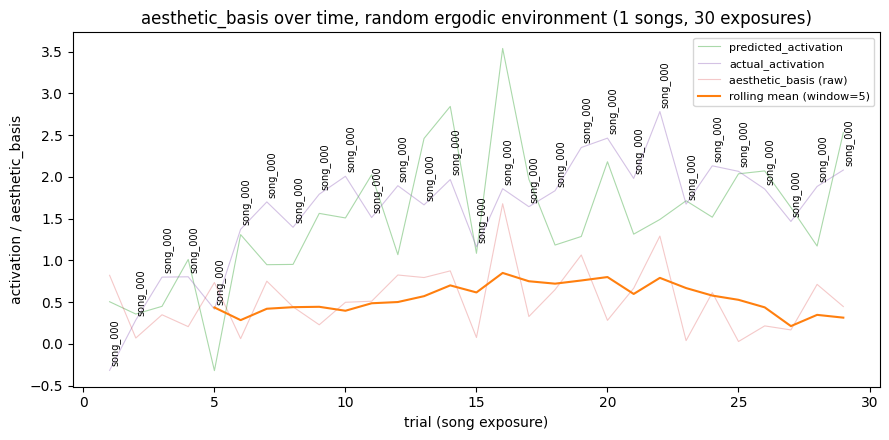

In [23]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(df["trial"], df["predicted_activation"], alpha=0.4, linewidth=0.8,
        color="tab:green", label="predicted_activation")
ax.plot(df["trial"], df["actual_activation"], alpha=0.4, linewidth=0.8,
        color="tab:purple", label="actual_activation")
ax.plot(df["trial"], df["aesthetic_basis"], alpha=0.25, linewidth=0.8,
        color="tab:red", label="aesthetic_basis (raw)")
ax.plot(df["trial"], df["aesthetic_basis_rolling_mean"], linewidth=1.5,
        color="tab:orange", label=f"rolling mean (window={WINDOW})")

if ANNOTATE_SONGS:
    step = max(1, len(df) // ANNOTATE_MAX_LABELS)
    for _, row in df.iloc[::step].iterrows():
        ax.annotate(row["actual_song_id"], (row["trial"], row["actual_activation"]),
                    fontsize=7, rotation=90, textcoords="offset points", xytext=(0, 5))

ax.set_xlabel("trial (song exposure)")
ax.set_ylabel("activation / aesthetic_basis")
ax.set_title(f"aesthetic_basis over time, random ergodic environment "
             f"({NUM_SONGS} songs, {NUM_EXPOSURES} exposures)")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig("../results/figures/design1_ergodic_timeseries.png", dpi=150)

If the environment is truly ergodic and the model reaches a steady state, we'd expect the rolling mean to flatten out (stop trending) as more of memory's history accumulates, fluctuating around some fixed level rather than drifting. Check the plot above for whether that's what happens, or whether there's a systematic trend (e.g., rising or falling aesthetic_basis) as songs accumulate more reference history.